# 1. Data Loading and Preprossessing

In [96]:
DATA_DIR = r"E:\fyp_qnn\data"
ticker = 'AAPL'
df = pd.read_parquet(DATA_DIR + r"\yfinance\\" + ticker + ".parquet").dropna()

In [97]:
df.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'}, inplace=True)

In [98]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import MinMaxScaler

def build_quantum_data_pipeline(df: pd.DataFrame, target_col: str = 'close', lookback: int = 2):
    """
    Implements the Data Preparation Pipeline from Figure 3.
    Requires a pandas DataFrame with 'open', 'high', 'low', 'close' columns.
    """
    data = df.copy()

    # 1. Calculate Technical Indicators (Simplified without external libraries)
    # RSI (14-day)
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # MACD (12, 26, 9)
    ema_12 = data['close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = ema_12 - ema_26
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

    # SMA (5, 20)
    data['SMA5'] = data['close'].rolling(window=5).mean()
    data['SMA20'] = data['close'].rolling(window=20).mean()

    # Drop NaNs created by rolling windows
    data = data.dropna()

    # Define features (X) and target (y)
    X = data.drop(columns=[target_col])
    y = data[target_col]

    # 2. Feature Selection (SelectKBest k=5)
    selector = SelectKBest(score_func=f_regression, k=5)
    X_selected = selector.fit_transform(X, y)

    selected_feature_names = X.columns[selector.get_support()]
    print(f"Selected 5 Features: {list(selected_feature_names)}")

    # 3. Quantum Normalization to [-1, 1]
    quantum_scaler = MinMaxScaler(feature_range=(-1.0, 1.0))
    X_quantum_scaled = quantum_scaler.fit_transform(X_selected)

    # Note: Fig 3 states the classical target is scaled to [0, 1]
    classical_scaler = MinMaxScaler(feature_range=(0, 1))
    y_scaled = classical_scaler.fit_transform(y.values.reshape(-1, 1))

    return X_quantum_scaled, y_scaled, quantum_scaler, classical_scaler

In [99]:
X,y,q_scaler,c_scaler = build_quantum_data_pipeline(df)
print(X.shape, y.shape, q_scaler, c_scaler)


Selected 5 Features: ['open', 'high', 'low', 'SMA5', 'SMA20']
(983, 5) (983, 1) MinMaxScaler(feature_range=(-1.0, 1.0)) MinMaxScaler()


# 2. Build Ansatz

In [100]:
from __future__ import annotations

from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Gate, ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.primitives import Sampler

DEFAULT_NUM_QUBITS = 5

def compute_angle_encoding(
    features: Sequence[float],
    f_transform=None,
    g_transform=None,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute the Fig. 4 angles defined in the paper."""

    x = np.asarray(features, dtype=float)
    f_values = x if f_transform is None else np.asarray(f_transform(x), dtype=float)
    g_values = x if g_transform is None else np.asarray(g_transform(x), dtype=float)
    theta = np.arcsin(np.clip(f_values, -1.0, 1.0))
    phi = np.arccos(np.clip(g_values, -1.0, 1.0))
    return theta, phi


def build_angle_encoding_circuit(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Build the angle encoding circuit from Fig. 4."""
    theta = ParameterVector('θ', num_qubits)
    phi = ParameterVector('φ', num_qubits)

    circuit = QuantumCircuit(num_qubits, name="fig4_angle_encoding")
    for qubit in range(num_qubits):
        circuit.ry(theta[qubit], qubit)
        circuit.rz(phi[qubit], qubit)
    return circuit


def ppr_gate(width: int) -> Gate:
    """Return the custom `Ppr(0)` gate shown in the paper's circuit."""

    gate = Gate(name="Ppr", num_qubits=width, params=[0])
    # The paper does not define Ppr separately. Treat it as an opaque labeled identity block so the reproduced circuit can still be simulated.
    gate.definition = QuantumCircuit(width)
    return gate


def build_custom_qnn_ansatz_circuit(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Transcribe Fig. 5: customized QNN ansatz.

    Reference parts:
    - `arxiv_source/fig5.pdf` supplies the exact visible gate order.
    - The CNOT pairs come from the blue control/target vector geometry.
    - `Ppr(0)` is implemented as a labeled identity block because the paper
      does not separately define the Ppr unitary.
    """

    if num_qubits != DEFAULT_NUM_QUBITS:
        raise ValueError("Fig. 5 is a five-qubit circuit.")

    circuit = QuantumCircuit(num_qubits, name="fig5_custom_qnn_ansatz")

    weights = ParameterVector('w', 50)
    w_idx = 0

    circuit.h(range(num_qubits))
    circuit.cx(0, 1)
    circuit.rz(weights[w_idx], 1); w_idx += 1
    circuit.cx(0, 1)

    circuit.cx(0, 2)
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.cx(0, 2)

    circuit.cx(1, 2)
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.cx(1, 2)

    circuit.cx(3, 4)
    circuit.rz(weights[w_idx], 4); w_idx += 1
    circuit.cx(3, 4)

    circuit.ry(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1
    circuit.ry(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1
    circuit.ry(weights[w_idx], 2); w_idx += 1
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.ry(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1
    circuit.ry(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1

    circuit.rx(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [0, 1])

    circuit.rx(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [1, 2])

    circuit.rx(weights[w_idx], 2); w_idx += 1
    circuit.rz(weights[w_idx], 2); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [2, 3])

    circuit.ry(weights[w_idx], 2); w_idx += 1
    circuit.ry(weights[w_idx], 2); w_idx += 1
    circuit.rx(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [3, 4])

    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.rx(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1
    circuit.cx(2, 3)

    ppr_gate = Gate(name="Ppr", num_qubits=5, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [0, 1, 2, 3, 4])

    circuit.ry(weights[w_idx], 0); w_idx += 1
    circuit.ry(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1
    circuit.ry(weights[w_idx], 3); w_idx += 1
    circuit.ry(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1
    circuit.ry(weights[w_idx], 4); w_idx += 1
    circuit.ry(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1

    circuit.cx(0, 1)
    circuit.ry(weights[w_idx], 1); w_idx += 1
    circuit.ry(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1

    return circuit


def build_angle_encoding_plus_ansatz(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Compose Fig. 4 angle encoding with the Fig. 5 QNN ansatz."""

    circuit = build_angle_encoding_circuit(num_qubits).compose(
        build_custom_qnn_ansatz_circuit(num_qubits)
    )
    circuit.name = "fig4_plus_fig5_custom_qnn_ansatz"
    return circuit


In [101]:
def build_qnn_regressor_circuit(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Transcribe Fig. 6: QNN Regressor circuit used in HybridQNN1.

    Reference parts:
    - The CNOT pairs come from the blue control/target vector geometry
    - The five `Ppr(0)` blocks are implemented as opaque Qiskit gates so the
      circuit remains runnable.
    """

    if num_qubits != DEFAULT_NUM_QUBITS:
        raise ValueError("Fig. 6 is a five-qubit circuit.")

    circuit = QuantumCircuit(num_qubits, name="fig6_qnn_regressor")

    # First line of the folded Qiskit drawing.
    circuit.h([0, 1, 2, 3, 4])
    circuit.cx(1, 2)
    circuit.cx(0, 4)
    circuit.rz(0, 2)
    circuit.rz(0, 4)
    circuit.cx(1, 2)
    circuit.cx(0, 4)
    circuit.ry(0, 0)
    circuit.ry(0, 4)
    circuit.cx(1, 3)
    circuit.rz(0, 0)
    circuit.rz(0, 3)
    circuit.rz(0, 4)
    circuit.rx(0, 0)
    circuit.cx(1, 3)
    circuit.rz(0, 0)
    circuit.ry(0, 1)
    circuit.cx(2, 3)
    circuit.rz(0, 1)
    circuit.rz(0, 3)
    circuit.append(ppr_gate(2), [0, 1])
    circuit.cx(2, 3)
    circuit.rx(0, 1)
    circuit.ry(0, 2)
    circuit.ry(0, 3)
    circuit.rz(0, 1)
    circuit.rz(0, 2)
    circuit.rz(0, 3)
    circuit.append(ppr_gate(2), [1, 2])
    circuit.rx(0, 2)
    circuit.rz(0, 2)
    circuit.append(ppr_gate(2), [2, 3])
    circuit.ry(0, 2)
    circuit.ry(0, 2)
    circuit.rx(0, 3)
    circuit.rz(0, 3)
    circuit.append(ppr_gate(2), [3, 4])
    circuit.rz(0, 2)
    circuit.rz(0, 2)
    circuit.rx(0, 4)
    circuit.rz(0, 4)
    circuit.cx(2, 3)
    circuit.append(ppr_gate(5), [0, 1, 2, 3, 4])
    circuit.ry(0, 0)
    circuit.ry(0, 3)
    circuit.ry(0, 4)

    # Continuation line
    circuit.ry(0, 0)
    circuit.rz(0, 0)
    circuit.rz(0, 0)
    circuit.cx(0, 1)
    circuit.ry(0, 1)
    circuit.ry(0, 1)
    circuit.rz(0, 1)
    circuit.rz(0, 1)
    circuit.ry(0, 3)
    circuit.rz(0, 3)
    circuit.rz(0, 3)
    circuit.ry(0, 4)
    circuit.rz(0, 4)
    circuit.rz(0, 4)

    return circuit


def build_full_qnn_pipeline(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Compose Fig. 4 angle encoding with the Fig. 6 QNN regressor."""

    circuit = build_angle_encoding_circuit(num_qubits).compose(
        build_qnn_regressor_circuit(num_qubits)
    )
    circuit.name = "fig4_plus_fig6_qnn_regressor"
    return circuit

# 3. Assembling the Network

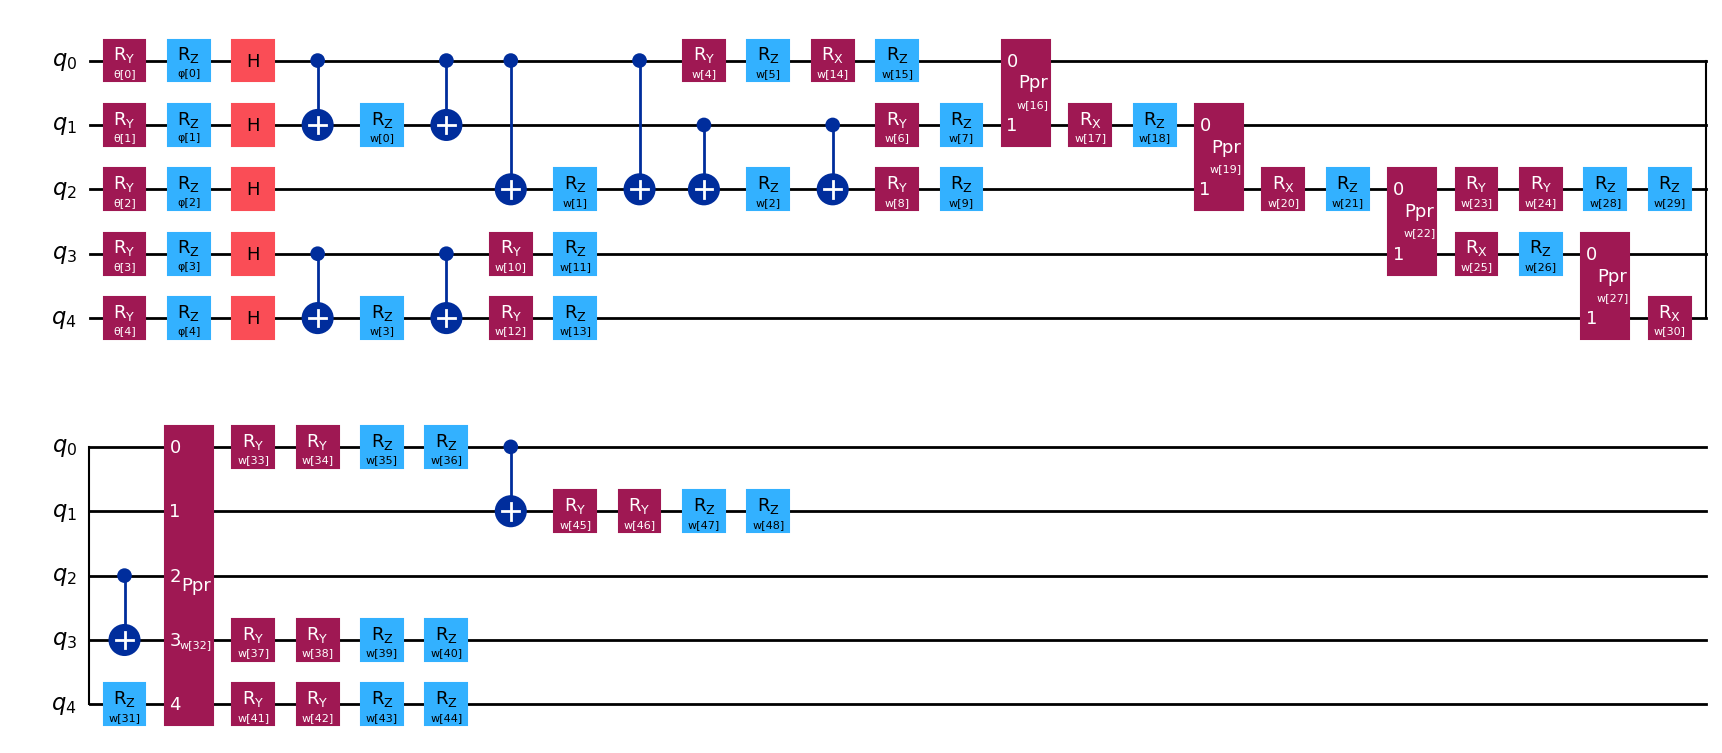

In [102]:
feature_map = build_angle_encoding_circuit(DEFAULT_NUM_QUBITS)
circuit = build_angle_encoding_plus_ansatz(DEFAULT_NUM_QUBITS)
circuit.draw(output='mpl')
    

## CustomQNN test-training pipeline (focused additions)

This section adds only the missing parts for end-to-end CustomQNN training:
1) data-to-model contract,
2) trainable model wrapper,
3) optimization loop,
4) time-series validation,
5) evaluation outputs.

In [110]:
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

import pennylane as qml

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda0"
print("Using device:", DEVICE)

Using device: cuda0


In [104]:
@dataclass
class RunConfig:
    data_dir: str = r"E:\fyp_qnn\data\yfinance"
    ticker: str = "AAPL"
    target_col: str = "close"
    lookback: int = 2
    k_features: int = 3
    n_qubits: int = 3
    n_layers: int = 2
    holdout_ratio: float = 0.2
    n_splits: int = 3
    epochs: int = 30
    lr: float = 1e-2
    batch_size: int = 32
    patience: int = 5

cfg = RunConfig()
assert cfg.k_features == cfg.n_qubits, "Set k_features == n_qubits for paper-style mapping."


def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    delta = out["close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    out["rsi_14"] = 100 - (100 / (1 + rs))

    ema_12 = out["close"].ewm(span=12, adjust=False).mean()
    ema_26 = out["close"].ewm(span=26, adjust=False).mean()
    out["macd"] = ema_12 - ema_26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()

    high_low = out["high"] - out["low"]
    high_close = (out["high"] - out["close"].shift(1)).abs()
    low_close = (out["low"] - out["close"].shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)

    up_move = out["high"].diff()
    down_move = -out["low"].diff()
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    atr_14 = tr.rolling(14).mean()
    plus_di = 100 * (pd.Series(plus_dm, index=out.index).rolling(14).mean() / (atr_14 + 1e-12))
    minus_di = 100 * (pd.Series(minus_dm, index=out.index).rolling(14).mean() / (atr_14 + 1e-12))
    dx = 100 * ((plus_di - minus_di).abs() / (plus_di + minus_di + 1e-12))
    out["adx_14"] = dx.rolling(14).mean()

    return out.dropna()


def make_sequences(X: np.ndarray, y: np.ndarray, lookback: int):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])
    return np.asarray(X_seq), np.asarray(y_seq)

In [105]:
raw = pd.read_parquet(f"{cfg.data_dir}\\{cfg.ticker}.parquet").dropna().copy()
raw = raw.rename(columns={"Open": "open", "High": "high", "Low": "low", "Close": "close"})
raw = add_technical_indicators(raw)

base_features = [
    "open", "high", "low", "close", "Volume",
    "rsi_14", "macd", "macd_signal", "adx_14",
]
base_features = [c for c in base_features if c in raw.columns]

X_all = raw[base_features]
y_all = raw[cfg.target_col].values.reshape(-1, 1)

split_idx = int(len(raw) * (1 - cfg.holdout_ratio))
X_trainval_df, X_test_df = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_trainval, y_test = y_all[:split_idx], y_all[split_idx:]

selector = SelectKBest(score_func=f_regression, k=cfg.k_features)
X_trainval_sel = selector.fit_transform(X_trainval_df, y_trainval.ravel())
X_test_sel = selector.transform(X_test_df)
selected_cols = X_trainval_df.columns[selector.get_support()].tolist()

x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))
X_trainval_scaled = x_scaler.fit_transform(X_trainval_sel)
X_test_scaled = x_scaler.transform(X_test_sel)
y_trainval_scaled = y_scaler.fit_transform(y_trainval)
y_test_scaled = y_scaler.transform(y_test)

X_trainval_seq, y_trainval_seq = make_sequences(X_trainval_scaled, y_trainval_scaled, cfg.lookback)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test_scaled, cfg.lookback)

print("Selected features:", selected_cols)
print("Train/val seq:", X_trainval_seq.shape, y_trainval_seq.shape)
print("Test seq:", X_test_seq.shape, y_test_seq.shape)

Selected features: ['open', 'high', 'low']
Train/val seq: (778, 2, 3) (778, 1)
Test seq: (194, 2, 3) (194, 1)


In [106]:
class CustomQNNRegressor(nn.Module):
    def __init__(self, lookback: int, n_features: int, n_qubits: int, n_layers: int):
        super().__init__()
        self.lookback = lookback
        self.n_features = n_features
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.input_proj = nn.Linear(lookback * n_features, n_qubits)
        self.output_head = nn.Linear(n_qubits, 1)

        self.q_weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 2))

        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def circuit(features, weights):
            clipped = qml.math.clip(features, -1.0, 1.0)
            for i in range(n_qubits):
                theta_i = qml.math.arcsin(clipped[i])
                phi_i = qml.math.arccos(clipped[i])
                qml.RY(theta_i, wires=i)
                qml.RZ(phi_i, wires=i)

            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RY(weights[l, i, 0], wires=i)
                    qml.RZ(weights[l, i, 1], wires=i)

                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                    qml.CZ(wires=[i, i + 1])

            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.qnode = circuit

    def forward(self, x):
        # x: (batch, lookback, n_features)
        bsz = x.size(0)
        x_flat = x.reshape(bsz, -1)
        encoded = torch.tanh(self.input_proj(x_flat))

        q_out = []
        for i in range(bsz):
            q_result = self.qnode(encoded[i], self.q_weights)
            q_out.append(torch.stack(q_result))
        q_out = torch.stack(q_out)

        # PennyLane commonly returns float64 tensors; align with torch layer dtype.
        q_out = q_out.to(dtype=encoded.dtype)

        pred = self.output_head(q_out)
        return pred.squeeze(-1)


model = CustomQNNRegressor(
    lookback=cfg.lookback,
    n_features=cfg.k_features,
    n_qubits=cfg.n_qubits,
    n_layers=cfg.n_layers,
).to(DEVICE)

print(model)

CustomQNNRegressor(
  (input_proj): Linear(in_features=6, out_features=3, bias=True)
  (output_head): Linear(in_features=3, out_features=1, bias=True)
)


In [ ]:
def run_fold_training(X_tr, y_tr, X_va, y_va, cfg: RunConfig):
    model = CustomQNNRegressor(cfg.lookback, cfg.k_features, cfg.n_qubits, cfg.n_layers).to(DEVICE)
    loss_fn = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=cfg.lr)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    y_tr_t = torch.tensor(y_tr.reshape(-1), dtype=torch.float32, device=DEVICE)
    X_va_t = torch.tensor(X_va, dtype=torch.float32, device=DEVICE)
    y_va_t = torch.tensor(y_va.reshape(-1), dtype=torch.float32, device=DEVICE)

    best_state = None
    best_val = float("inf")
    patience_count = 0
    history = {"train_rmse": [], "val_rmse": []}

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        optimizer.zero_grad()
        pred_tr = model(X_tr_t)
        loss = loss_fn(pred_tr, y_tr_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_va = model(X_va_t)
            val_loss = loss_fn(pred_va, y_va_t)

        train_rmse = float(torch.sqrt(loss.detach()).cpu())
        val_rmse = float(torch.sqrt(val_loss.detach()).cpu())
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        scheduler.step(val_loss)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | train_rmse={train_rmse:.5f} | val_rmse={val_rmse:.5f}")

        if patience_count >= cfg.patience:
            print(f"Early stopping at epoch {epoch} (patience={cfg.patience}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


tscv = TimeSeriesSplit(n_splits=cfg.n_splits)
fold_models = []
fold_histories = []
fold_rmses_scaled = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_trainval_seq), start=1):
    print(f"\n--- Fold {fold}/{cfg.n_splits} ---")
    X_tr, y_tr = X_trainval_seq[tr_idx], y_trainval_seq[tr_idx]
    X_va, y_va = X_trainval_seq[va_idx], y_trainval_seq[va_idx]

    fold_model, fold_hist = run_fold_training(X_tr, y_tr, X_va, y_va, cfg)
    fold_models.append(fold_model)
    fold_histories.append(fold_hist)

    with torch.no_grad():
        X_va_t = torch.tensor(X_va, dtype=torch.float32, device=DEVICE)
        pred_va = fold_model(X_va_t).cpu().numpy().reshape(-1, 1)

    va_mse = mean_squared_error(y_va.reshape(-1, 1), pred_va)
    va_rmse = float(np.sqrt(va_mse))
    fold_rmses_scaled.append(va_rmse)
    print(f"Fold {fold} scaled RMSE: {va_rmse:.6f}")

print("\nScaled fold RMSEs:", [round(v, 6) for v in fold_rmses_scaled])
print("Mean scaled RMSE:", round(float(np.mean(fold_rmses_scaled)), 6))


--- Fold 1/3 ---
Epoch 01 | train_rmse=0.52199 | val_rmse=0.40804
Epoch 05 | train_rmse=0.26322 | val_rmse=0.16537
Epoch 10 | train_rmse=0.06710 | val_rmse=0.10425
Early stopping at epoch 13 (patience=5).
Fold 1 scaled RMSE: 0.038328

--- Fold 2/3 ---
Epoch 01 | train_rmse=0.77506 | val_rmse=0.96124
Epoch 05 | train_rmse=0.59223 | val_rmse=0.79183
Epoch 10 | train_rmse=0.39617 | val_rmse=0.59487
Epoch 15 | train_rmse=0.25831 | val_rmse=0.43150
Epoch 20 | train_rmse=0.18348 | val_rmse=0.31034
Epoch 25 | train_rmse=0.15067 | val_rmse=0.22958
Epoch 30 | train_rmse=0.12833 | val_rmse=0.18113
Fold 2 scaled RMSE: 0.181133

--- Fold 3/3 ---
Epoch 01 | train_rmse=0.79975 | val_rmse=1.23045
Epoch 05 | train_rmse=0.61760 | val_rmse=1.07642
Epoch 10 | train_rmse=0.41251 | val_rmse=0.89034
Epoch 15 | train_rmse=0.25514 | val_rmse=0.72317
Epoch 20 | train_rmse=0.17958 | val_rmse=0.59308
Epoch 25 | train_rmse=0.16693 | val_rmse=0.51590
Epoch 30 | train_rmse=0.14967 | val_rmse=0.48972
Fold 3 scaled 

Using fold 1 model for held-out test evaluation.
Held-out test RMSE (original price scale): 105.276434


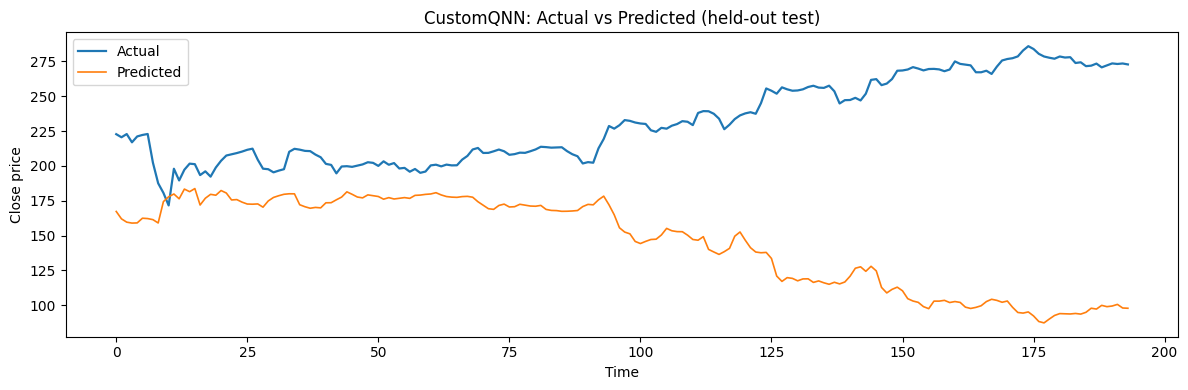

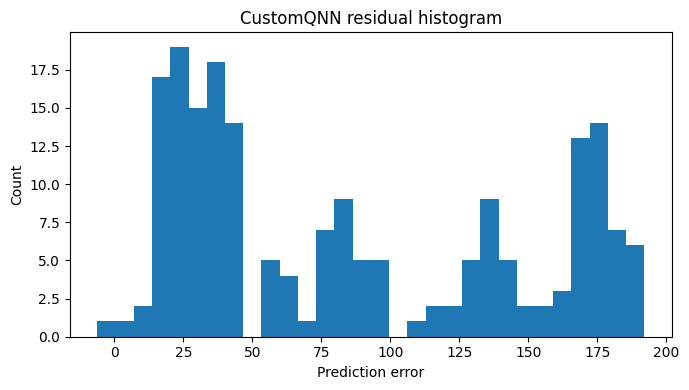

In [109]:
best_fold = int(np.argmin(fold_rmses_scaled))
best_model = fold_models[best_fold]
print(f"Using fold {best_fold + 1} model for held-out test evaluation.")

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    y_test_pred_scaled = best_model(X_test_t).cpu().numpy().reshape(-1, 1)

y_test_true = y_scaler.inverse_transform(y_test_seq)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

rmse_test = float(np.sqrt(mean_squared_error(y_test_true, y_test_pred)))
print(f"Held-out test RMSE (original price scale): {rmse_test:.6f}")

plt.figure(figsize=(12, 4))
plt.plot(y_test_true, label="Actual", linewidth=1.6)
plt.plot(y_test_pred, label="Predicted", linewidth=1.2)
plt.title("CustomQNN: Actual vs Predicted (held-out test)")
plt.xlabel("Time")
plt.ylabel("Close price")
plt.legend()
plt.tight_layout()
plt.show()

errors = (y_test_true - y_test_pred).reshape(-1)
plt.figure(figsize=(7, 4))
plt.hist(errors, bins=30)
plt.title("CustomQNN residual histogram")
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.tight_layout()
plt.show()